# **Tech Challenge Fase 1 | Case NPS Preditivo | Pós-Tech FIAP**

---

##### Modelo Preditivo de NPS

Construir um modelo preditivo capaz de antecipar se um cliente se tornará Promotor ou Não-Promotor com base nos dados operacionais do pedido, antes da aplicação da pesquisa de NPS.

---

## Estratégia Adotada

### Por que Classificação em vez de Regressão?

Dois caminhos seriam possíveis:

| Abordagem | Pergunta respondida | Vantagem | Limitação |
|-----------|--------------------|-----------|-----------|
| **Regressão** | Qual será a nota exata? | Granularidade máxima | Difícil de usar operacionalmente — saber se a nota será 5.2 ou 5.8 não muda a ação |
| **Classificação** | O cliente será Promotor? | Diretamente acionável — permite criar alertas e priorizar intervenções | Perde granularidade da nota |

Optamos por **classificação binária** porque é mais acionável para o negócio: a equipe de CRM pode ser alertada sobre clientes com baixa probabilidade de serem promotores e agir preventivamente.

**Definição da target binária:**
- **Promotor (1):** NPS >= 9
- **Não-Promotor (0):** NPS < 9 (inclui neutros e detratores)

### Por que Random Forest?

- Robusto a outliers e features em escalas diferentes
- Captura relações não-lineares entre variáveis
- Fornece importância de features interpretável para o negócio
- Não requer normalização das features
- Baseline com Regressão Logística para comparação

---

## 0. Imports e Configurações

In [1]:
# Bibliotecas de analise, visualizacao e modelagem
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')  # suprimir avisos de versao que nao afetam os resultados

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
import joblib

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Garantir que as pastas de saida existem antes de salvar figuras e modelos
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)
print('Ambiente configurado com sucesso.')

Ambiente configurado com sucesso.


---
## 1. Carregamento e Definição da Variável Alvo

In [2]:
# Carrega o dataset e define a variavel alvo binaria: 1=Promotor (NPS>=9), 0=Nao-Promotor
df = pd.read_csv('../data/desafio_nps_fase_1.csv')

# Variável alvo: Promotor (NPS >= 9) = 1, Não-Promotor = 0
df['target'] = (df['nps_score'] >= 9).astype(int)

print('Distribuição da variável alvo (target):')
contagem = df['target'].value_counts()
for val, qtd in contagem.items():
    label = 'Promotor' if val == 1 else 'Nao-Promotor'
    print(f'  {label} (={val}): {qtd} ({qtd/len(df):.1%})')

print(f'\nTotal de registros: {len(df)}')

Distribuição da variável alvo (target):
  Nao-Promotor (=0): 2390 (95.6%)
  Promotor (=1): 110 (4.4%)

Total de registros: 2500


---
## 2. Seleção e Preparação das Features

### Variáveis excluídas e justificativas:

| Variável | Motivo da exclusão |
|----------|--------------------|
| `customer_id` | Identificador — sem valor preditivo |
| `order_id` | Identificador — sem valor preditivo |
| `nps_score` | É a origem da variável alvo — não pode ser usada como feature |
| `csat_internal_score` | **Data leakage**: score interno fortemente correlacionado com NPS, pode ser derivado dele |
| `repeat_purchase_30d` | **Data leakage**: recompra pode acontecer simultaneamente ou após o NPS — não disponível no momento da predição em produção |

In [3]:
# Colunas removidas: IDs sem poder preditivo, variavel alvo e colunas com risco de data leakage
COLUNAS_EXCLUIR = [
    'customer_id',
    'order_id',
    'nps_score',
    'target',
    'csat_internal_score',
    'repeat_purchase_30d'
]

# Separar features (X) e variavel alvo (y)
X = df.drop(columns=COLUNAS_EXCLUIR)
y = df['target']

# One-Hot Encoding da regiao: drop_first=True evita multicolinearidade (dummy trap)
X = pd.get_dummies(X, columns=['customer_region'], drop_first=True, dtype=int)

print(f'Features utilizadas ({X.shape[1]} no total):')
for col in X.columns:
    print(f'  - {col}')

Features utilizadas (17 no total):
  - customer_age
  - customer_tenure_months
  - order_value
  - items_quantity
  - discount_value
  - payment_installments
  - delivery_time_days
  - delivery_delay_days
  - freight_value
  - delivery_attempts
  - customer_service_contacts
  - resolution_time_days
  - complaints_count
  - customer_region_Nordeste
  - customer_region_Norte
  - customer_region_Sudeste
  - customer_region_Sul


---
## 3. Análise do Balanceamento da Target

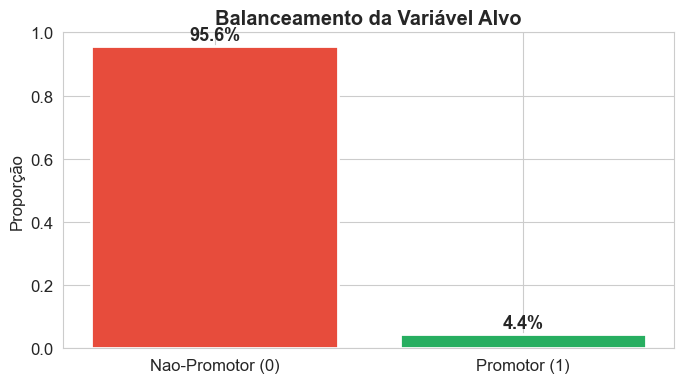

Proporção Promotores:    4.4%
Proporção Nao-Promotores: 95.6%

Estrategia: usar class_weight="balanced" nos modelos para lidar com eventual desbalanceamento.


In [4]:
# Calcular proporcoes para avaliar o grau de desbalanceamento da variavel alvo
prop_promotor = y.mean()
prop_nao_promotor = 1 - prop_promotor

# Etapa de construção de gráfico de barras para exibir o desbalanceamento entre as classes
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Nao-Promotor (0)', 'Promotor (1)'],
       [prop_nao_promotor, prop_promotor],
       color=['#e74c3c', '#27ae60'], edgecolor='white', linewidth=2)
ax.set_title('Balanceamento da Variável Alvo', fontweight='bold')
ax.set_ylabel('Proporção')
ax.set_ylim(0, 1)
for i, v in enumerate([prop_nao_promotor, prop_promotor]):
    ax.text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/N03_01_balanceamento_target.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Proporção Promotores:    {prop_promotor:.1%}')
print(f'Proporção Nao-Promotores: {prop_nao_promotor:.1%}')
print()
print('Estrategia: usar class_weight="balanced" nos modelos para lidar com eventual desbalanceamento.')

---
## 4. Separação Treino / Teste

**Lógica de separação:**
- 80% para treino e 20% para teste
- `stratify=y` garante que a proporção de promotores seja mantida em ambos os conjuntos
- `random_state=42` garante reprodutibilidade dos resultados

In [5]:
# Divisao 80/20 com stratify para manter a proporcao de promotores em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Conjunto de treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X):.0%})')
print(f'Conjunto de teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X):.0%})')
print()
print(f'Promotores no treino: {y_train.mean():.1%}')
print(f'Promotores no teste:  {y_test.mean():.1%}')
print('\nBalanceamento preservado entre treino e teste.')

Conjunto de treino: 2000 amostras (80%)
Conjunto de teste:  500 amostras (20%)

Promotores no treino: 4.4%
Promotores no teste:  4.4%

Balanceamento preservado entre treino e teste.


---
## 5. Modelo Baseline — Regressão Logística

Serve como referência mínima de performance: qualquer modelo mais sofisticado deve superar este baseline.

In [6]:
# Normalizacao obrigatoria para Regressao Logistica: sensivel a escala das features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',  # compensa o desbalanceamento: 95.6% Nao-Promotores vs 4.4% Promotores
    max_iter=1000              # aumentado pois o dataset tem features em escalas muito diferentes
)
lr.fit(X_train_scaled, y_train)

# Gerar predicoes de classe e probabilidades para avaliacao
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)

print('=== REGRESSÃO LOGÍSTICA (Baseline) ===')
print(classification_report(y_test, y_pred_lr, target_names=['Nao-Promotor', 'Promotor']))
print(f'ROC-AUC: {auc_lr:.4f}')

=== REGRESSÃO LOGÍSTICA (Baseline) ===
              precision    recall  f1-score   support

Nao-Promotor       0.99      0.80      0.89       478
    Promotor       0.16      0.82      0.27        22

    accuracy                           0.80       500
   macro avg       0.57      0.81      0.58       500
weighted avg       0.95      0.80      0.86       500

ROC-AUC: 0.8642


---
## 6. Modelo Principal — Random Forest

**Parâmetros escolhidos:**
- `n_estimators=200`: 200 árvores — equilíbrio entre performance e tempo de treino
- `max_depth=10`: limita profundidade para evitar overfitting
- `min_samples_split=10`, `min_samples_leaf=5`: regularização para árvores mais robustas
- `class_weight='balanced'`: compensa eventual desbalanceamento da target

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          # profundidade limitada para evitar overfitting em dataset pequeno
    min_samples_split=10,  # minimo de amostras para dividir um no interno
    min_samples_leaf=5,    # minimo de amostras em cada folha — regularizacao adicional
    class_weight='balanced',  # compensa o desbalanceamento: 95.6% Nao-Promotores vs 4.4% Promotores
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Gerar predicoes de classe e probabilidades no conjunto de teste
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print('=== RANDOM FOREST (Modelo Principal) ===')
print(classification_report(y_test, y_pred_rf, target_names=['Nao-Promotor', 'Promotor']))
print(f'ROC-AUC: {auc_rf:.4f}')

=== RANDOM FOREST (Modelo Principal) ===
              precision    recall  f1-score   support

Nao-Promotor       0.98      0.94      0.96       478
    Promotor       0.29      0.55      0.38        22

    accuracy                           0.92       500
   macro avg       0.64      0.74      0.67       500
weighted avg       0.95      0.92      0.93       500

ROC-AUC: 0.9060


---
## 7. Avaliação Visual dos Modelos

### 7.1 Matriz de Confusão e Curva ROC

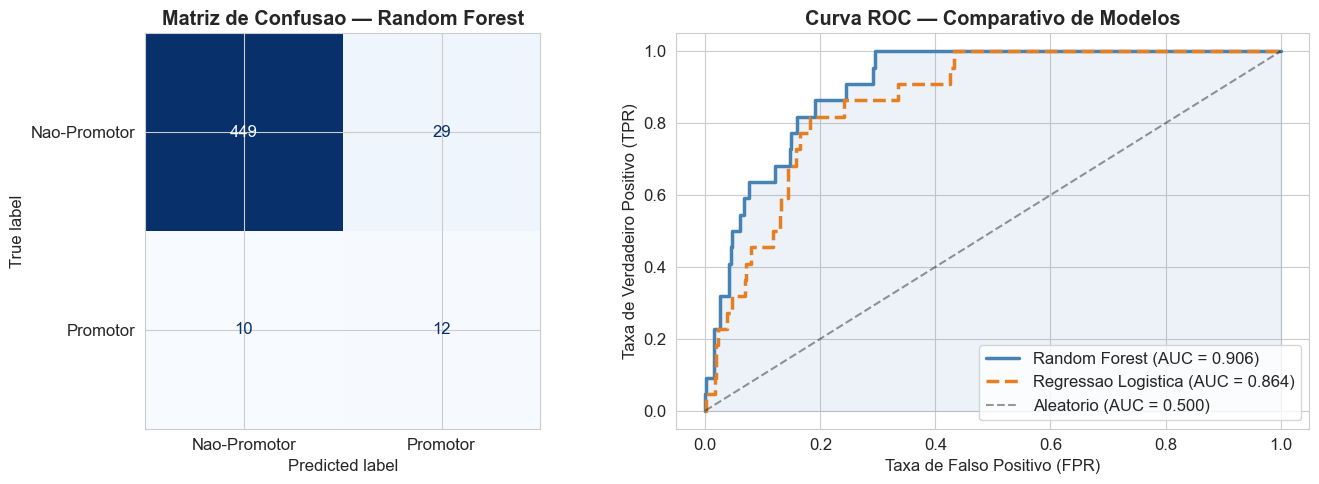

In [8]:
# Etapa de construção de gráfico duplo para exibir matriz de confusao (erros por tipo) + curva ROC (comparativo de modelos)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix: Random Forest ---
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Nao-Promotor', 'Promotor'])
disp_rf.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusao — Random Forest', fontweight='bold')

# --- ROC Curves ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

axes[1].plot(fpr_rf, tpr_rf, linewidth=2.5, color='steelblue',
             label=f'Random Forest (AUC = {auc_rf:.3f})')
axes[1].plot(fpr_lr, tpr_lr, linewidth=2.5, color='#e67e22', linestyle='--',
             label=f'Regressao Logistica (AUC = {auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio (AUC = 0.500)')
axes[1].fill_between(fpr_rf, tpr_rf, alpha=0.1, color='steelblue')
axes[1].set_xlabel('Taxa de Falso Positivo (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo (TPR)')
axes[1].set_title('Curva ROC — Comparativo de Modelos', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/N03_02_avaliacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Comparativo de Métricas

In [9]:
# Consolidar todas as metricas de avaliacao em um DataFrame para comparacao direta
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

resultados = pd.DataFrame({
    'Modelo': ['Regressao Logistica (baseline)', 'Random Forest'],
    'Acuracia': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precisao (Promotor)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall (Promotor)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score (Promotor)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [auc_lr, auc_rf]
})

resultados = resultados.round(4)
print('=== COMPARATIVO DE MÉTRICAS ===')
print(resultados.to_string(index=False))

=== COMPARATIVO DE MÉTRICAS ===
                        Modelo  Acuracia  Precisao (Promotor)  Recall (Promotor)  F1-Score (Promotor)  ROC-AUC
Regressao Logistica (baseline)     0.802               0.1593             0.8182               0.2667   0.8642
                 Random Forest     0.922               0.2927             0.5455               0.3810   0.9060


---
## 8. Importância das Variáveis (Feature Importance)

**Pergunta:** Quais fatores operacionais têm maior poder de prever se um cliente será Promotor?

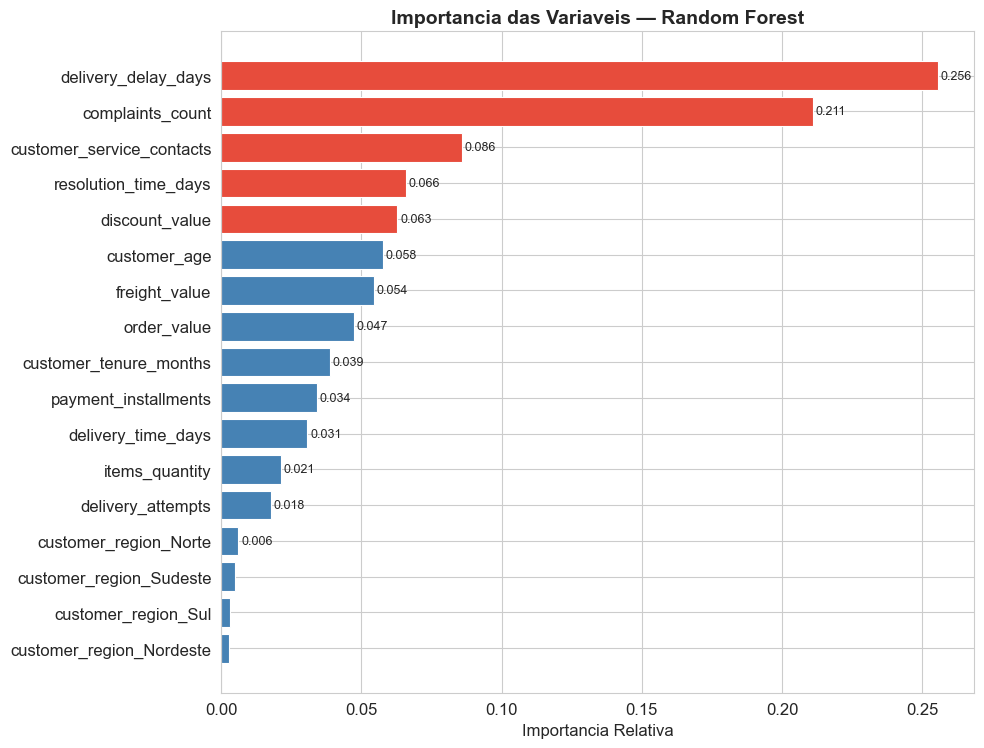


Top 10 variaveis mais importantes:
                  feature  importance
      delivery_delay_days    0.255694
         complaints_count    0.210979
customer_service_contacts    0.085734
     resolution_time_days    0.065960
           discount_value    0.062846
             customer_age    0.057563
            freight_value    0.054493
              order_value    0.047252
   customer_tenure_months    0.038647
     payment_installments    0.034186


In [10]:
# Extrair e ordenar a importancia de cada feature segundo o Random Forest
feature_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

# Top 5 features destacadas em vermelho para facilitar leitura do grafico
n_features = len(feature_imp)
cores_fi = ['#e74c3c' if i >= n_features - 5 else 'steelblue'
            for i in range(n_features)]

# Etapa de construção de gráfico de barras horizontal para exibir importancia relativa de cada variavel no modelo
fig, ax = plt.subplots(figsize=(10, max(6, n_features * 0.45)))
bars = ax.barh(feature_imp['feature'], feature_imp['importance'],
               color=cores_fi, edgecolor='white', linewidth=0.8)

ax.set_title('Importancia das Variaveis — Random Forest', fontweight='bold', fontsize=14)
ax.set_xlabel('Importancia Relativa')

# Labels
for bar in bars:
    width = bar.get_width()
    if width > 0.005:
        ax.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/N03_03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 variaveis mais importantes:')
print(feature_imp.tail(10)[['feature', 'importance']]
      .sort_values('importance', ascending=False)
      .to_string(index=False))

---
## 9. Validação Cruzada

In [11]:
# Validacao cruzada 5-fold: avalia estabilidade do modelo em diferentes subconjuntos dos dados
cv_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
# Mesmo procedimento para o baseline de Regressao Logistica
cv_scores_lr = cross_val_score(lr, scaler.fit_transform(X), y, cv=5, scoring='roc_auc', n_jobs=-1)

print('=== VALIDAÇÃO CRUZADA (5-fold, ROC-AUC) ===')
print(f'Random Forest:       {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')
print(f'Regressao Logistica: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})')
print()
print('Scores individuais por fold (RF):', np.round(cv_scores_rf, 4))

=== VALIDAÇÃO CRUZADA (5-fold, ROC-AUC) ===
Random Forest:       0.8803 (+/- 0.0373)
Regressao Logistica: 0.8890 (+/- 0.0280)

Scores individuais por fold (RF): [0.8148 0.9218 0.8819 0.9101 0.873 ]


---
## 10. Salvar o Modelo

In [12]:
# Persistir modelo, scaler e lista de colunas para uso em producao
joblib.dump(rf, '../models/random_forest_nps.pkl')
joblib.dump(scaler, '../models/scaler_lr.pkl')
# Salvar a lista de colunas garante que a ordem das features seja identica em producao
joblib.dump(list(X.columns), '../models/feature_columns.pkl')

print('Artefatos salvos em ../models/:')
print('  random_forest_nps.pkl  — modelo Random Forest treinado')
print('  scaler_lr.pkl          — StandardScaler para Regressao Logistica')
print('  feature_columns.pkl    — lista de colunas de entrada na ordem correta')

Artefatos salvos em ../models/:
  random_forest_nps.pkl  — modelo Random Forest treinado
  scaler_lr.pkl          — StandardScaler para Regressao Logistica
  feature_columns.pkl    — lista de colunas de entrada na ordem correta


---
## 11. Como Usar o Modelo em Produção

Esta seção simula como o modelo seria utilizado na prática — recebendo dados operacionais de um novo pedido e retornando a probabilidade de o cliente ser promotor, antes da pesquisa NPS ser enviada.

In [13]:
def prever_nps(dados_pedido: dict, modelo, colunas_modelo) -> dict:
    """
    Recebe os dados operacionais de um pedido e retorna a previsao de NPS.
    """
    df_input = pd.DataFrame([dados_pedido])
    df_input = pd.get_dummies(df_input, columns=['customer_region'], dtype=int)

    # Garantir que todas as colunas do modelo estejam presentes
    for col in colunas_modelo:
        if col not in df_input.columns:
            df_input[col] = 0
    df_input = df_input[colunas_modelo]

    prob_promotor = modelo.predict_proba(df_input)[0][1]
    # threshold 0.5 pode ser ajustado: abaixar aumenta recall (pega mais detratores),
    # elevar aumenta precisao (menos falsos alarmes) — depende do custo de cada erro para o negocio
    classificacao = 'PROMOTOR' if prob_promotor >= 0.5 else 'NAO-PROMOTOR'
    risco = 'BAIXO' if prob_promotor >= 0.7 else ('MEDIO' if prob_promotor >= 0.4 else 'ALTO')

    return {
        'probabilidade_promotor': round(prob_promotor, 4),
        'classificacao': classificacao,
        'risco_detrator': risco
    }


# Carregar artefatos salvos para simulacao de uso em producao
modelo_carregado = joblib.load('../models/random_forest_nps.pkl')
colunas_salvas = joblib.load('../models/feature_columns.pkl')


# Cenario 1: cliente sem atraso, sem contato com SAC e sem reclamacoes
# --- Exemplo 1: Pedido com experiencia positiva ---
pedido_positivo = {
    'customer_age': 42,
    'customer_tenure_months': 36,
    'order_value': 350.0,
    'items_quantity': 2,
    'discount_value': 10.0,
    'payment_installments': 3,
    'delivery_time_days': 4,
    'delivery_delay_days': 0,
    'freight_value': 20.0,
    'delivery_attempts': 1,
    'customer_service_contacts': 0,
    'resolution_time_days': 0,
    'complaints_count': 0,
    'customer_region': 'Sudeste'
}

resultado1 = prever_nps(pedido_positivo, modelo_carregado, colunas_salvas)
print('=== EXEMPLO 1: Pedido com experiencia positiva ===')
print(f'  Probabilidade de Promotor: {resultado1["probabilidade_promotor"]:.1%}')
print(f'  Classificacao:             {resultado1["classificacao"]}')
print(f'  Risco de Detrator:         {resultado1["risco_detrator"]}')
print()


# Cenario 2: cliente com atraso severo, multiplos contatos SAC e reclamacoes
# --- Exemplo 2: Pedido com experiencia negativa ---
pedido_negativo = {
    'customer_age': 28,
    'customer_tenure_months': 3,
    'order_value': 280.0,
    'items_quantity': 4,
    'discount_value': 5.0,
    'payment_installments': 6,
    'delivery_time_days': 14,
    'delivery_delay_days': 6,
    'freight_value': 50.0,
    'delivery_attempts': 3,
    'customer_service_contacts': 4,
    'resolution_time_days': 9,
    'complaints_count': 3,
    'customer_region': 'Nordeste'
}

resultado2 = prever_nps(pedido_negativo, modelo_carregado, colunas_salvas)
print('=== EXEMPLO 2: Pedido com experiencia negativa ===')
print(f'  Probabilidade de Promotor: {resultado2["probabilidade_promotor"]:.1%}')
print(f'  Classificacao:             {resultado2["classificacao"]}')
print(f'  Risco de Detrator:         {resultado2["risco_detrator"]}')

=== EXEMPLO 1: Pedido com experiencia positiva ===
  Probabilidade de Promotor: 78.2%
  Classificacao:             PROMOTOR
  Risco de Detrator:         BAIXO

=== EXEMPLO 2: Pedido com experiencia negativa ===
  Probabilidade de Promotor: 3.7%
  Classificacao:             NAO-PROMOTOR
  Risco de Detrator:         ALTO


---
## 12. Interpretação de Negócio e Uso Prático

### Como esse modelo pode ser utilizado na prática?

**Fluxo operacional proposto:**

```
[Pedido entregue]
      |
      v
[Sistema coleta dados operacionais: atraso, tentativas, contatos SAC, reclamações]
      |
      v
[Modelo calcula probabilidade de promotor]
      |
      +---> Prob >= 70%  --> VERDE: cliente com alta chance de ser promotor
      |                     Acao: enviar pesquisa NPS padrão + convite para review
      |
      +---> Prob 40-70%  --> AMARELO: cliente com risco moderado
      |                     Acao: monitorar e aguardar feedback espontâneo
      |
      +---> Prob < 40%   --> VERMELHO: cliente com alta chance de ser detrator
                            Acao: acionar equipe de CX proativamente antes do NPS
                            Acao: oferecer cupom de desconto, contato personalizado
```

### Valor gerado para o negócio:

| Situação atual | Com o modelo preditivo |
|----------------|------------------------|
| NPS coletado só depois da experiência — sem ação possível | Previsão feita logo após a entrega — ação preventiva antes do NPS |
| Tratamento igual para todos os clientes | Priorização dos clientes de maior risco de virar detrator |
| Alto custo de recuperação de clientes detratores | Baixo custo de prevenção: contato proativo + pequeno incentivo |
| Sem visão operacional preditiva | Dashboard em tempo real com probabilidade de NPS por pedido |

### Limitações e riscos:

1. **Tamanho da amostra:** ~2.500 registros é um dataset razoável, mas modelos de produção se beneficiariam de dados históricos maiores.
2. **Drift ao longo do tempo:** O comportamento dos clientes muda — o modelo precisa ser retreinado periodicamente.
3. **Fatores não capturados:** Qualidade do produto, sazonalidade, promoções especiais e eventos externos não estão no dataset.
4. **Viés de resposta:** Se o dataset original só capturou clientes que responderam ao NPS, pode haver viés de seleção.
5. **Limiar de decisão (threshold):** O threshold de 0.5 pode ser ajustado dependendo do custo de falsos positivos vs falsos negativos para o negócio.

---

## Conclusão

O modelo Random Forest consegue identificar padrões nos dados operacionais que precedem um NPS alto ou baixo. As variáveis mais importantes confirmam os achados da EDA: **atraso na entrega, contatos com o SAC e número de reclamações** são os principais preditores de um cliente insatisfeito.

Com esse modelo, a empresa pode **agir preventivamente**, transformando uma métrica reativa em uma ferramenta proativa de gestão da experiência do cliente.